In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

In [ ]:
# Load the dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')


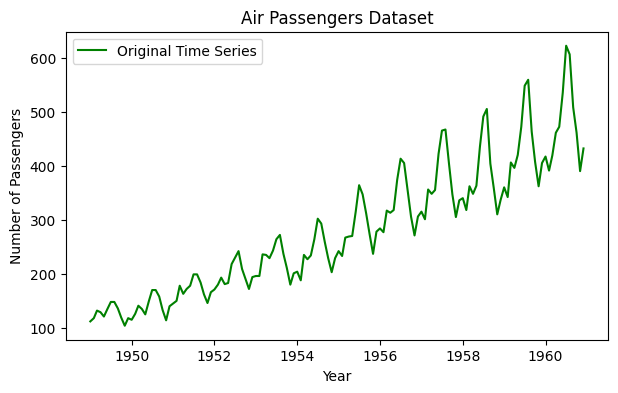

In [ ]:
# Plot the original time series
plt.figure(figsize=(7, 4))
plt.plot(df.index, df['Passengers'], label='Original Time Series', color='green')
plt.title('Air Passengers Dataset')
plt.xlabel('Year')
plt.ylabel('Number of Passengers')
plt.legend()
plt.show()

The above plot is the raw time-series of the dataset where we have plotted the 'Year' to the X-axis and 'Number of Passengers' to the Y-axis. From this plot we can see the there is a presence of similar pattern or seasonal component which is being repeated with the forward of X-axis which is 'Year' or time-interval.

In [ ]:

# Perform STL decomposition
stl = STL(df['Passengers'], seasonal=13, robust=True)
result = stl.fit()



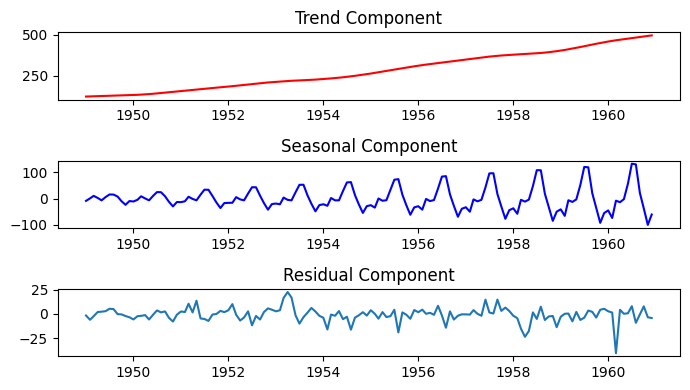

In [ ]:
# Plot the decomposition components
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(7, 4))
ax1.plot(df.index, result.trend, label='Trend', color='red')
ax1.set_title('Trend Component')
ax2.plot(df.index, result.seasonal, label='Seasonal', color='blue')
ax2.set_title('Seasonal Component')
ax3.plot(df.index, result.resid, label='Residual')
ax3.set_title('Residual Component')
plt.tight_layout()
plt.show()

The above plot consists of all time-series components which are trend, seasonal and residual. As we have already seen in raw dataset plot that the seasonal component is repeated with higher magnitude when we go forward with X-axis. Here also, we can visualize that the seasonal component is increasing gradually with time. However, the trend component is very straight forward without any sudden change and residual component presents that the dataset has noises but not high yet.

In [ ]:
# Create a deseasonalized time series
deseasonalized_series = df['Passengers'] - result.seasonal



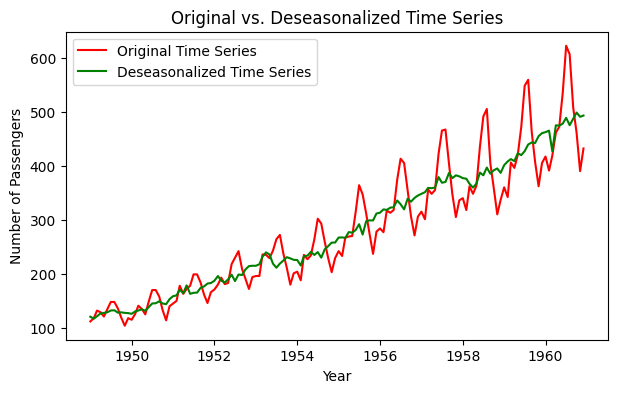

In [ ]:
# visualize the comparative plot
plt.figure(figsize=(7, 4))
plt.plot(df.index, df['Passengers'], label='Original Time Series', color='red')
plt.plot(df.index, deseasonalized_series, label='Deseasonalized Time Series', color='green')
plt.title('Original vs. Deseasonalized Time Series')
plt.xlabel('Year')
plt.ylabel('Number of Passengers')
plt.legend()
plt.show()

The above plot is the comparative plot between original and de-seasonalized time-series which correctly shows that how easy and simple the data looks like when we remove the seasonal component. Now this de-seasonalized data can be useful for various further complex tasks like forecasting and recommendation system where model training is required. It is always suggested to perform seasonal decomposition and removal in time-series data to make it accurate for model predictions.

To conclude that ,  Loess (STL) is an effective technique to decompose time-series data and make it smooth and normalized.